In [1]:
import gymnasium as gym
import ale_py
from stable_baselines3 import PPO
from stable_baselines3.common.atari_wrappers import AtariWrapper

# Register Atari environments
gym.register_envs(ale_py)

# Create environment WITH rendering
env = gym.make("ALE/KingKong-v5", render_mode="human")
env = AtariWrapper(env)

from stable_baselines3 import DQN

model = DQN.load("kingkong_dqn.zip")

# Run the model
obs, _ = env.reset()

while True:
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, _ = env.step(action)

    if terminated or truncated:
        obs, _ = env.reset()

KeyboardInterrupt: 

In [5]:
import gymnasium as gym
import ale_py
from stable_baselines3 import PPO
from stable_baselines3.common.atari_wrappers import AtariWrapper

# Register Atari environments
gym.register_envs(ale_py)

# Create environment WITH rendering
env = gym.make("ALE/KingKong-v5", render_mode="human")
env = AtariWrapper(env)

model1 = PPO.load("kingkong_ppo3.zip")

# Run the model
obs, _ = env.reset()

while True:
    action, _ = model.predict(obs)
    obs, reward, terminated, truncated, _ = env.step(action)

    if terminated or truncated:
        obs, _ = env.reset()

KeyboardInterrupt: 

In [3]:
def collect_rewards(model, env, n_episodes=20):
    rewards = []

    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        total_reward = 0

        while not done:
            action, _ = model.predict(obs, deterministic=True)
            obs, reward, terminated, truncated, _ = env.step(action)
            total_reward += reward
            done = terminated or truncated

        rewards.append(total_reward)

    return rewards

In [7]:
dqn_rewards = collect_rewards(model, env)

In [8]:
ppo_rewards = collect_rewards(model1, env)

Text(0.5, 1.0, 'Learning Comparison')

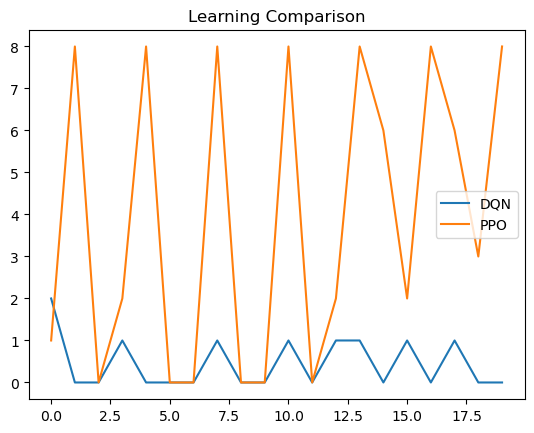

In [13]:
import matplotlib.pyplot as plt

plt.plot(dqn_rewards, label="DQN")
plt.plot(ppo_rewards, label="PPO")
plt.legend()
plt.title("Learning Comparison")

C:\Users\ddoris\AppData\Local\Temp\ipykernel_16984\2930238658.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([dqn_rewards, ppo_rewards], labels=["DQN", "PPO"])


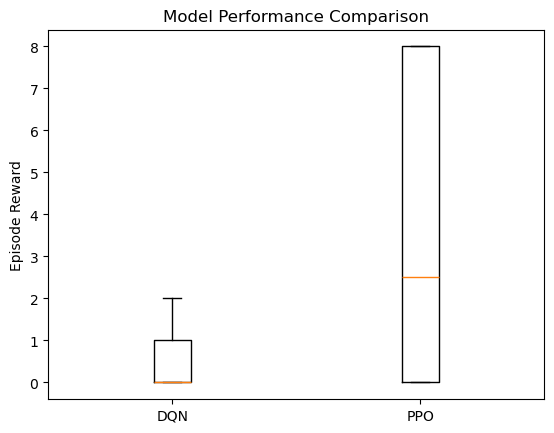

In [14]:
import matplotlib.pyplot as plt

plt.figure()

plt.boxplot([dqn_rewards, ppo_rewards], labels=["DQN", "PPO"])

plt.title("Model Performance Comparison")
plt.ylabel("Episode Reward")

plt.show()

In [10]:
import numpy as np

print("DQN mean:", np.mean(dqn_rewards))
print("DQN std:", np.std(dqn_rewards))

print("PPO mean:", np.mean(ppo_rewards))
print("PPO std:", np.std(ppo_rewards))

DQN mean: 0.45
DQN std: 0.5894913061275798
PPO mean: 3.9
PPO std: 3.4481879299133333


In [9]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(dqn_rewards, ppo_rewards)

print("t-stat:", t_stat)
print("p-value:", p_value)

t-stat: -4.298822795364429
p-value: 0.0001152392423533968


In [11]:
import scipy.stats as stats

def confidence_interval(data):
    return stats.t.interval(
        0.95,
        len(data)-1,
        loc=np.mean(data),
        scale=stats.sem(data)
    )

print("DQN CI:", confidence_interval(dqn_rewards))
print("PPO CI:", confidence_interval(ppo_rewards))

DQN CI: (np.float64(0.1669423977085014), np.float64(0.7330576022914986))
PPO CI: (np.float64(2.2442744658892098), np.float64(5.55572553411079))
